In [7]:
# Import libs
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import sys
import matplotlib.pyplot as plt

In [13]:
# Function to bin data with specified bin width
def bin_data(values, bin_width=0.3, range_min=-3, range_max=3):
    num_bins = int((range_max - range_min) / bin_width)
    bins = np.linspace(range_min, range_max, num_bins + 1)
    bin_indices = np.digitize(values, bins) - 1  # Subtract 1 to convert to 0-indexed
    y_binned = np.clip(bin_indices, 0, num_bins - 1)  # Ensure indices are within valid range
    y_one_hot = to_categorical(y_binned, num_bins)
    return y_one_hot, num_bins, bins[:-1]  # Return the bins minus the last bin edge


In [32]:
def get_labels(arr):
    start = -12
    for i in range(0,arr.shape[1],12):
        start = i
        end  = i+12

        if i ==0:
            label = arr[:,start:end]
        else:
            label = np.concatenate((label,arr[:,start:end]),axis=0)

    return label

In [30]:
# Function to calculate the weighted average for the top-k predictions using bin values
def weighted_average_top_k(predictions, bin_values, top_k=5):

    batch_size = predictions.shape[0]
    weighted_averages = np.zeros((batch_size,12))

    for j in range(predictions.shape[1]):
        # Get the indices of the top-k predictions
        prediction = predictions[:,j,:]
        top_k_indices = np.argsort(prediction, axis=1)[:, -top_k:]

        # Get the probabilities of the top-k predictions
        top_k_probs = np.take_along_axis(prediction, top_k_indices, axis=1)

        # Get the bin values for the top-k predictions
        top_k_bin_values = np.take_along_axis(bin_values[np.newaxis, :], top_k_indices, axis=1)

        # Calculate the weighted average for each input in the batch
        class_weighted_averages = np.zeros(batch_size)
        for i in range(batch_size):
            class_weighted_averages[i] = np.sum(top_k_bin_values[i] * top_k_probs[i]) / np.sum(top_k_probs[i])
        
        weighted_averages[:,j] = class_weighted_averages
        
    return weighted_averages

In [34]:
data_aa = np.load('../change_aa.npy')
test_label = get_labels(data_aa[100:150,:])
del data_aa

In [2]:
yhat = np.load('predicted_model1_raw_probabilities.npy')
yhat.shape

(12, 82350, 20)

In [3]:
yhat_reshaped = np.zeros((82350,12,20))
yhat_reshaped.shape

(82350, 12, 20)

In [4]:
for i in range(12):
    yhat_reshaped[:,i,:] = yhat[i,:,:]
    

In [5]:
yhat_reshaped.shape

(82350, 12, 20)

In [6]:
yhat_reshaped[100,:,:] == yhat[:,100,:].reshape(-1,12,20)

array([[[ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,
          True, 

In [8]:
yhat_reshaped[0,0,:]

array([1.91938354e-10, 2.09431222e-10, 1.90138383e-06, 3.58884409e-03,
       5.17508201e-02, 8.89377072e-02, 7.39868432e-02, 6.32833317e-02,
       6.56229481e-02, 7.78498575e-02, 9.78200063e-02, 1.02727324e-01,
       1.18984945e-01, 9.23262611e-02, 1.10376090e-01, 5.12998849e-02,
       1.44314975e-03, 2.34095965e-10, 2.02755535e-10, 2.38862041e-10])

In [15]:

# Example train_label data
train_label = np.array([0.5, -1.5, 2.3, 0.8, -2.1, 1.7])  # Example labels

# Bin the data
y_test, num_bins, bin_values = bin_data(train_label, bin_width=0.3)
num_bins,bin_values

(20,
 array([-3. , -2.7, -2.4, -2.1, -1.8, -1.5, -1.2, -0.9, -0.6, -0.3,  0. ,
         0.3,  0.6,  0.9,  1.2,  1.5,  1.8,  2.1,  2.4,  2.7]))

In [19]:

# Dummy predictions for a batch of 2 inputs, with num_bins categories each
predictions = np.random.rand(2, num_bins)



# Example usage
final_predictions = weighted_average_top_k(predictions, bin_values, top_k=5)

print("Final predictions:", final_predictions)


Final predictions: [0.01359743 0.11183345]


(None, (2, 20))

In [51]:
final_predictions = weighted_average_top_k(yhat_reshaped, bin_values, top_k=1)


print("Final predictions:", final_predictions)


Final predictions: [[ 0.6  0.9 -1.5 ... -1.2 -0.9 -0.9]
 [ 0.6 -0.3 -0.9 ... -1.2  0.  -0.9]
 [ 0.6 -0.3 -0.9 ... -1.2 -0.9 -0.9]
 ...
 [ 1.2 -0.6  0.  ... -1.5 -0.3 -0.9]
 [ 1.2 -0.6  0.  ... -0.9 -0.3 -0.6]
 [ 1.2 -0.6  0.  ... -0.9 -0.3  0. ]]


In [38]:
test_label[0]

array([ 0.434,  0.207, -1.425, -0.786,  0.087, -0.635, -0.346,  0.317,
        0.825,  0.334, -0.543,  1.415])

In [39]:
final_predictions[0]

array([ 0.60845086,  0.12066332, -0.31787217, -0.02321055,  0.01516408,
       -0.00551283, -0.3176159 , -0.23659724, -0.2412151 , -0.85806728,
       -0.59170728, -0.32057948])

(array([1.65330e+04, 7.37150e+04, 1.72691e+05, 1.96743e+05, 1.99603e+05,
        1.88537e+05, 9.90980e+04, 3.98600e+04, 1.37000e+03, 5.00000e+01]),
 array([-1.956 , -1.4876, -1.0192, -0.5508, -0.0824,  0.386 ,  0.8544,
         1.3228,  1.7912,  2.2596,  2.728 ]),
 <BarContainer object of 10 artists>)

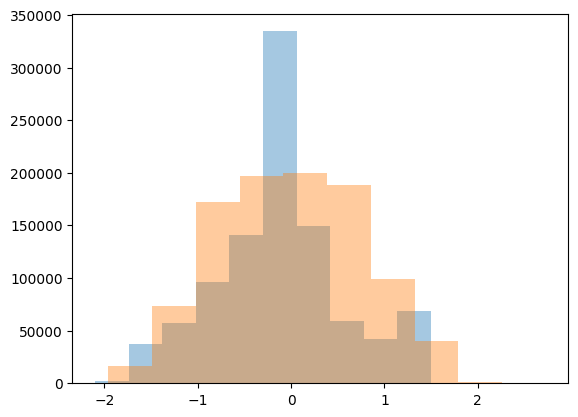

In [52]:
plt.hist(final_predictions.reshape(-1,1),alpha=0.4)
plt.hist(test_label.reshape(-1,1),alpha=0.4)